In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, RobustScaler

In [12]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'UNSW_NB15_training-set.csv', 'drive', 'UNSW.zip', 'sample_data']


In [14]:

df = pd.read_csv('UNSW_NB15_training-set.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [15]:
print("Dataset Shape:", df.shape)
df.head()
df.info()
print(df.columns)

Dataset Shape: (82332, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  


In [16]:
missing = df.isnull().sum()
print(missing)
print("Total Missing Values:", df.isnull().sum().sum())

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [17]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("unknown")

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [18]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)
print("Remaining Duplicates:", df.duplicated().sum())
print("New Shape:", df.shape)


Duplicate Rows: 0
Remaining Duplicates: 0
New Shape: (82332, 45)


In [19]:
print(df['attack_cat'].value_counts())

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


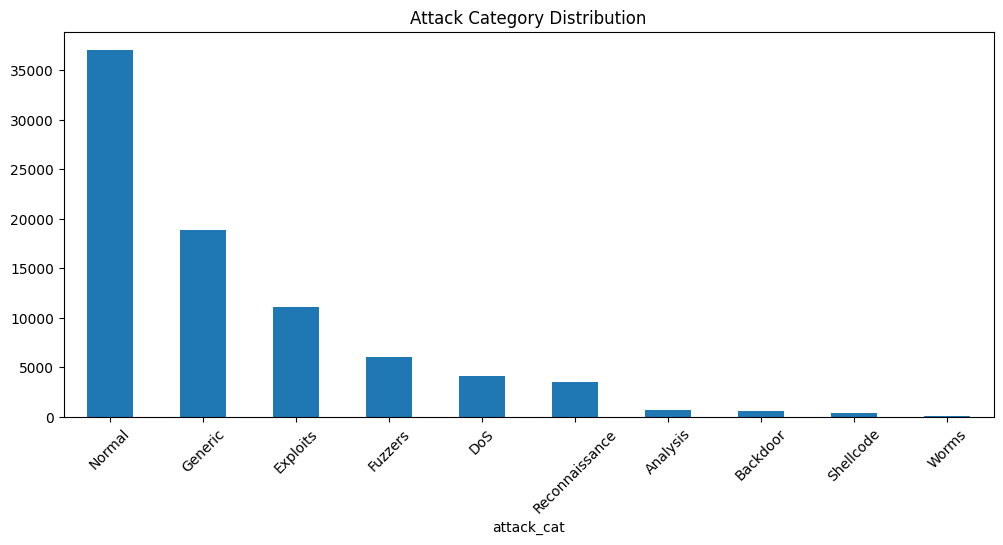

In [20]:
df['attack_cat'].value_counts().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Attack Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [21]:
print(df['label'].value_counts())
df.describe()

label
1    45332
0    37000
Name: count, dtype: int64


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [22]:
for col in num_cols:
    if (df[col] < 0).any():
        print("Negative values found in:", col)

for col in cat_cols:
    print("\n", col)
    print(df[col].unique())


 proto
['udp' 'arp' 'tcp' 'igmp' 'ospf' 'sctp' 'gre' 'ggp' 'ip' 'ipnip' 'st2'
 'argus' 'chaos' 'egp' 'emcon' 'nvp' 'pup' 'xnet' 'mux' 'dcn' 'hmp' 'prm'
 'trunk-1' 'trunk-2' 'xns-idp' 'leaf-1' 'leaf-2' 'irtp' 'rdp' 'netblt'
 'mfe-nsp' 'merit-inp' '3pc' 'idpr' 'ddp' 'idpr-cmtp' 'tp++' 'ipv6' 'sdrp'
 'ipv6-frag' 'ipv6-route' 'idrp' 'mhrp' 'i-nlsp' 'rvd' 'mobile' 'narp'
 'skip' 'tlsp' 'ipv6-no' 'any' 'ipv6-opts' 'cftp' 'sat-expak' 'ippc'
 'kryptolan' 'sat-mon' 'cpnx' 'wsn' 'pvp' 'br-sat-mon' 'sun-nd' 'wb-mon'
 'vmtp' 'ttp' 'vines' 'nsfnet-igp' 'dgp' 'eigrp' 'tcf' 'sprite-rpc' 'larp'
 'mtp' 'ax.25' 'ipip' 'aes-sp3-d' 'micp' 'encap' 'pri-enc' 'gmtp' 'ifmp'
 'pnni' 'qnx' 'scps' 'cbt' 'bbn-rcc' 'igp' 'bna' 'swipe' 'visa' 'ipcv'
 'cphb' 'iso-tp4' 'wb-expak' 'sep' 'secure-vmtp' 'xtp' 'il' 'rsvp' 'unas'
 'fc' 'iso-ip' 'etherip' 'pim' 'aris' 'a/n' 'ipcomp' 'snp' 'compaq-peer'
 'ipx-n-ip' 'pgm' 'vrrp' 'l2tp' 'zero' 'ddx' 'iatp' 'stp' 'srp' 'uti' 'sm'
 'smp' 'isis' 'ptp' 'fire' 'crtp' 'crudp' 'scco

In [23]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

print(df.columns)
print(df.dtypes)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss

In [24]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


In [25]:
feature_cols = ['proto', 'service', 'state']

encoders = {}

for col in feature_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df[feature_cols].head()

,proto,service,state
0,117,0,4
1,117,0,4
2,117,0,4
3,117,0,4
4,117,0,4


In [26]:
target_encoder = LabelEncoder()
df['attack_cat'] = target_encoder.fit_transform(df['attack_cat'])

print(
    dict(
        zip(
            target_encoder.classes_,
            target_encoder.transform(
                target_encoder.classes_
            )
        )
    )
)

{'Analysis': np.int64(0), 'Backdoor': np.int64(1), 'DoS': np.int64(2), 'Exploits': np.int64(3), 'Fuzzers': np.int64(4), 'Generic': np.int64(5), 'Normal': np.int64(6), 'Reconnaissance': np.int64(7), 'Shellcode': np.int64(8), 'Worms': np.int64(9)}


In [27]:
X = df.drop(['attack_cat', 'label'], axis=1)
y = df['attack_cat']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (82332, 42)
Target Shape: (82332,)


In [32]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.96385012e-02  1.00000000e+00  0.00000000e+00  1.00000000e+00
  -4.00000000e-01 -2.00000000e-01 -3.25900515e-02 -1.86192469e-01
   7.94534807e-01  0.00000000e+00 -1.15079365e-01  2.76035720e+00
  -1.33241295e-01 -3.33333333e-01  0.00000000e+00 -8.62643598e-03
  -1.58387316e-04 -5.47440160e-03  0.00000000e+00 -1.00000000e+00
  -1.28442553e-02 -1.33241673e-02 -1.00000000e+00 -5.22073228e-03
  -8.38474774e-03 -1.63879856e-03  4.25581395e+00 -5.05747126e-01
   0.00000000e+00  0.00000000e+00 -3.33333333e-01  1.00000000e+00
  -2.00000000e-01  0.00000000e+00  0.00000000e+00 -2.00000000e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.33333333e-01
  -3.33333333e-01  0.00000000e+00]
 [-1.96426716e-02  1.00000000e+00  0.00000000e+00  1.00000000e+00
  -4.00000000e-01 -2.00000000e-01  1.05317324e+00 -1.86192469e-01
   1.10143202e+00  0.00000000e+00 -1.15079365e-01  1.35175901e+01
  -1.33241295e-01 -3.33333333e-01  0.00000000e+00 -8.67375352e-03
  -1.58387316e-04 -5.47440160e-03  0.0000

In [29]:
cleaned_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

cleaned_df['attack_cat'] = y

cleaned_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,-0.019639,1.0,0.0,1.0,-0.4,-0.2,-0.032590,-0.186192,0.794535,0.0,...,0.000000,0.0,-0.2,0.0,0.0,0.0,-0.333333,-0.333333,0.0,6
1,-0.019643,1.0,0.0,1.0,-0.4,-0.2,1.053173,-0.186192,1.101432,0.0,...,0.000000,0.0,-0.2,0.0,0.0,0.0,-0.333333,-0.333333,0.0,6
2,-0.019647,1.0,0.0,1.0,-0.4,-0.2,0.457976,-0.186192,1.776606,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,-0.333333,-0.222222,0.0,6
3,-0.019645,1.0,0.0,1.0,-0.4,-0.2,0.313894,-0.186192,1.476529,0.0,...,0.333333,0.0,0.0,0.0,0.0,0.0,-0.166667,-0.222222,0.0,6
4,-0.019640,1.0,0.0,1.0,-0.4,-0.2,1.365352,-0.186192,0.876374,0.0,...,0.333333,0.0,0.0,0.0,0.0,0.0,-0.166667,-0.222222,0.0,6


In [30]:
print("Shape:", cleaned_df.shape)
print("Missing Values:", cleaned_df.isnull().sum().sum())
print("Duplicates:", cleaned_df.duplicated().sum())

Shape: (82332, 43)
Missing Values: 0
Duplicates: 26387


In [31]:
cleaned_df.to_csv(
    "cleaned_UNSW_NB15.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
